# OceanHeart：亲眼看 Agent 怎样调用工具（v2 数据 vs v3.1 数据）

选择 **OceanHeart Agents SDK** 内核，按顺序「全部运行」。只做本地推理：不训练、不调用在线 judge、不需要 API Key。

本页对比两个 Dense 权重。它们的起点权重、运行环境（OpenAI Agents SDK 循环）、两个海洋工具和评分规则完全相同，**只有工具 SFT 的训练数据不同**：

- **旧模型**：ReAct v2 数据训练（`ocean_react-v2-20260927-1046-sft_best`），每类题只有几种固定句式。
- **新模型**：ReAct v3.1 数据训练（`ocean_react-v3.1-20261006-1539-contrast-sft_best`），问法多样、运算均衡，并补了对比样本。

内容：① 结果总览（图表＋表格）；② 工具本身；③ 同一道题新旧模型各答一次；④ 上一轮的典型失败现在如何；⑤ 自己出题。**这是功能观察，不是新的基准；错误会原样展示。**

首次配置（终端执行；当前机器已配置）：
```bash
/home/anhuang/.venvs/ocean-agents-sdk/bin/pip install ipykernel nbformat nbclient
/home/anhuang/.venvs/ocean-agents-sdk/bin/python -m ipykernel install --user --name ocean-agents-sdk --display-name 'OceanHeart Agents SDK'
```

In [1]:
import asyncio
import json
import sys
from collections import Counter
from datetime import datetime
from importlib.metadata import version
from pathlib import Path

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "agent/sdk.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请从 OceanHeart 项目或其子目录打开 Notebook")
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
from transformers import AutoTokenizer
from agent.ocean import TOOLS, read_jsonl, file_hash
from agent.react import ReactTools
from agent.sdk import run, run_trajectory
from model.model_minimind import MiniMindConfig, MiniMindForCausalLM
from trainer.train_agent import model_generator, atomic_json

WEIGHTS = {  # 名称: 权重文件（Git 不包含权重，需要本机已有）
    "旧模型（v2 数据）": ROOT / "out/ocean_react-v2-20260927-1046-sft_best_768.pth",
    "新模型（v3.1 数据）": ROOT / "out/ocean_react-v3.1-20261006-1539-contrast-sft_best_768.pth",
}
SHORT = dict(zip(WEIGHTS, ["old", "new"]))
REACT_V2 = ROOT / "data/processed/react-v2"     # 旧模型那一轮的题：问法对新模型是没见过的
REACT_V31 = ROOT / "data/processed/react-v3.1"  # 自己出题时用的本地资料库
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"  # 可改为其他空闲显卡
for path in [*WEIGHTS.values(), REACT_V2 / "ocean_agent_val.jsonl", REACT_V31 / "ocean_agent_corpus_val.jsonl"]:
    if not path.is_file():
        raise FileNotFoundError(f"缺少本地资产：{path}；Git 不包含权重或生成数据")

torch.set_num_threads(2)
torch.manual_seed(42)
tokenizer = AutoTokenizer.from_pretrained(ROOT / "model", local_files_only=True)
print("内核：", sys.executable)
print("SDK：", version("openai-agents"), "  设备：", DEVICE)
for name, path in WEIGHTS.items():
    print(f"{name}：{path.name}")

/home/anhuang/.conda/envs/minimind/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/home/anhuang/.conda/envs/minimind/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


内核： /home/anhuang/.venvs/ocean-agents-sdk/bin/python
SDK： 0.22.3   设备： cuda:0
旧模型（v2 数据）：ocean_react-v2-20260927-1046-sft_best_768.pth
新模型（v3.1 数据）：ocean_react-v3.1-20261006-1539-contrast-sft_best_768.pth


## 1. 结果总览：三版模型在同一批题上的成功率

下面直接读取训练流水线保存的评估结果（不重新计算）。三版模型从同一个起点权重出发、用同样的设置训练，只换数据：

- **旧模型**：ReAct v2 数据（固定句式）。
- **v3**：多样化措辞、运算均衡。
- **v3.1**：v3 加上针对剩余失败的对比样本，也就是本页的「新模型」。

评估集：react-v2 验证/测试是旧模型那一轮的题，问法对 v3 / v3.1 都是**没见过的**；v1 旧任务检查有没有遗忘；react-v3 / v3.1 测试是新数据里留出的问法族。「成功」＝最终答案和必要的工具步骤都通过原评分规则。

注意：v3.1 的补丁是看过 react-v2 测试集的失败类型后设计的（措辞不重合），所以 react-v2 测试上的提升不算完全盲测；react-v3.1 测试更干净。

In [2]:
RUNS = ROOT / "artifacts/agent"
MODELS = ["旧模型（v2 数据）", "v3（多样化措辞）", "v3.1（+对比样本）"]
EVAL_SETS = {  # 评估集: 旧模型 / v3 / v3.1 的结果目录
    "react-v2 验证\n150 题": ("react-v2-20260927-1046-c-val", "react-v3-20261006-1314-fixed-v2-val",
                               "react-v3.1-20261006-1539-contrast-v2-val"),
    "react-v2 测试\n300 题": ("react-v2-20260927-1046-c-test", "react-v3-20261006-1314-fixed-v2-test",
                               "react-v3.1-20261006-1539-contrast-v2-test"),
    "v1 旧任务\n50 题": ("react-v2-20260927-1046-c-regression", "react-v3-20261006-1314-fixed-v1-regression",
                          "react-v3.1-20261006-1539-contrast-v1-regression"),
    "react-v3 测试\n300 题": ("react-v3.1-20261006-1539-old-v3-test", "react-v3-20261006-1314-fixed-v3-test",
                               "react-v3.1-20261006-1539-contrast-v3-test"),
    "react-v3.1 测试\n300 题": ("react-v3.1-20261006-1539-old-v3.1-test", "react-v3.1-20261006-1539-prev-v3.1-test",
                                 "react-v3.1-20261006-1539-contrast-v3.1-test"),
}
KINDS = {"calculate": "计算", "retrieve": "检索引用", "chain": "检索后计算",
         "recovery": "错误恢复", "clarify": "澄清", "direct": "直接回答"}
results = {(s, m): json.loads((RUNS / d / "result.json").read_text())
           for s, dirs in EVAL_SETS.items() for m, d in zip(MODELS, dirs)}
overall = pd.DataFrame([[results[s, m]["success"] * 100 for m in MODELS] for s in EVAL_SETS],
                       index=[s.replace("\n", "，") for s in EVAL_SETS], columns=MODELS)
overall.round(1)  # 单位：%

,旧模型（v2 数据）,v3（多样化措辞）,v3.1（+对比样本）
react-v2 验证，150 题,48.7,80.7,82.0
react-v2 测试，300 题,21.3,49.3,79.3
v1 旧任务，50 题,48.0,96.0,98.0
react-v3 测试，300 题,21.7,74.7,75.0
react-v3.1 测试，300 题,20.0,63.7,77.3


In [3]:
# 逐题配对比较：同一道题新旧各答一次，统计净提升；括号内是按题重抽样的 95% 区间（单位：百分点）
comparison = json.loads((RUNS / "react-v3.1-20261006-1539/comparison.json").read_text())
fmt = lambda p: f"{p['delta_success'] * 100:+.1f}（{p['paired_bootstrap_95ci'][0] * 100:+.1f}～{p['paired_bootstrap_95ci'][1] * 100:+.1f}）"
rows = []
for key, label in zip(["v2-val", "v2-test", "v1-regression", "v3-test", "v3.1-test"], overall.index):
    old, prev = (comparison[part][f"contrast/{key}"] for part in ("paired_vs_react_v2_sft", "paired_vs_previous"))
    rows.append([label, fmt(old), f"{old['improved']} / {old['regressed']}", fmt(prev), f"{prev['improved']} / {prev['regressed']}"])
pd.DataFrame(rows, columns=["评估集", "v3.1 − 旧模型", "变好/变差题数（对旧模型）",
                            "v3.1 − v3", "变好/变差题数（对 v3）"]).set_index("评估集")

,v3.1 − 旧模型,变好/变差题数（对旧模型）,v3.1 − v3,变好/变差题数（对 v3）
评估集,,,,
react-v2 验证，150 题,+33.3（+24.7～+42.0）,56 / 6,+1.3（-4.0～+6.7）,9 / 7
react-v2 测试，300 题,+58.0（+52.3～+63.7）,174 / 0,+30.0（+24.3～+35.7）,96 / 6
v1 旧任务，50 题,+50.0（+36.0～+64.0）,25 / 0,+2.0（+0.0～+6.0）,1 / 0
react-v3 测试，300 题,+53.3（+47.3～+59.0）,162 / 2,+0.3（-3.0～+3.7）,13 / 12
react-v3.1 测试，300 题,+57.3（+51.7～+63.0）,172 / 0,+13.7（+9.0～+18.3）,48 / 7


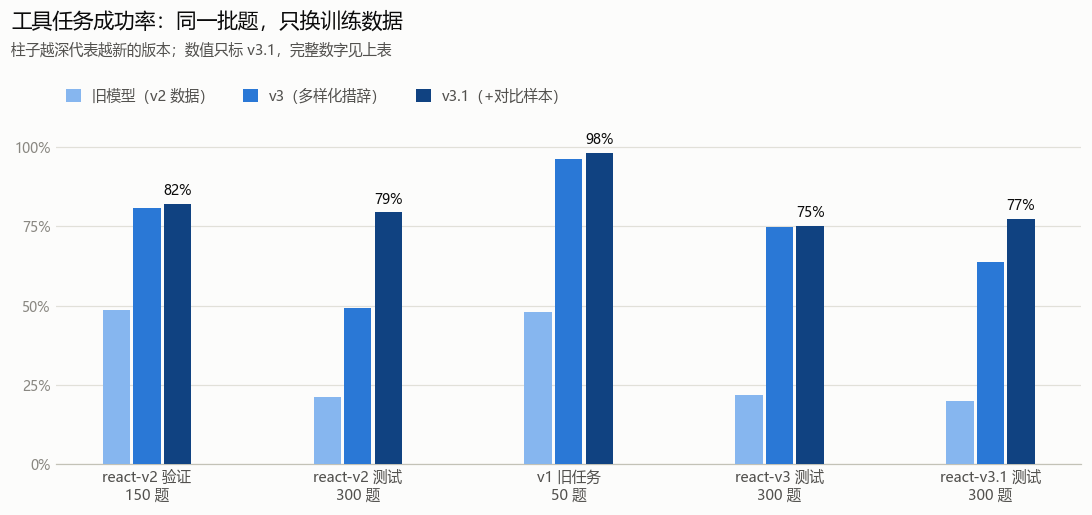

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

available = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family": [f for f in ("Microsoft YaHei", "Noto Sans CJK JP", "SimHei") if f in available]
                     + ["DejaVu Sans"], "axes.unicode_minus": False})
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
COLORS = dict(zip(MODELS, ["#86b6ef", "#2a78d6", "#104281"]))  # 版本有先后：越新越深（单色阶，已做色觉校验）


def grouped_bars(table, title, subtitle):
    fig, ax = plt.subplots(figsize=(10, 4.8), dpi=110, facecolor=INK["surface"])
    ax.set_facecolor(INK["surface"])
    x, width, gap = np.arange(len(table)), 0.13, 0.015
    for i, model in enumerate(table.columns):
        bars = ax.bar(x + (i - 1) * (width + gap), table[model], width, color=COLORS[model], label=model, zorder=3)
        if i == len(table.columns) - 1:  # 只标最新版本的数值，其余见表格
            for bar, value in zip(bars, table[model]):
                ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.0f}%",
                        ha="center", va="bottom", fontsize=9, color=INK["primary"])
    ax.set_xticks(x, [s.replace("，", "\n") for s in table.index], color=INK["secondary"], fontsize=9.5)
    ax.set_ylim(0, 110)
    ax.set_yticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"], color=INK["muted"], fontsize=9)
    ax.grid(axis="y", color=INK["grid"], linewidth=0.8, zorder=0)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(INK["axis"])
    ax.tick_params(length=0)
    ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=9.5,
              labelcolor=INK["secondary"], handlelength=1, handleheight=1, borderaxespad=0.3)
    fig.text(0.012, 0.965, title, fontsize=13.5, color=INK["primary"], va="top")
    fig.text(0.012, 0.905, subtitle, fontsize=9.5, color=INK["secondary"], va="top")
    fig.tight_layout(rect=(0, 0, 1, 0.86))
    plt.show()


grouped_bars(overall, "工具任务成功率：同一批题，只换训练数据", "柱子越深代表越新的版本；数值只标 v3.1，完整数字见上表")

,旧模型（v2 数据）,v3（多样化措辞）,v3.1（+对比样本）
计算,14.0,46.0,58.0
检索引用,2.0,90.0,92.0
检索后计算,0.0,2.0,100.0
错误恢复,80.0,98.0,98.0
澄清,4.0,34.0,30.0
直接回答,28.0,26.0,98.0


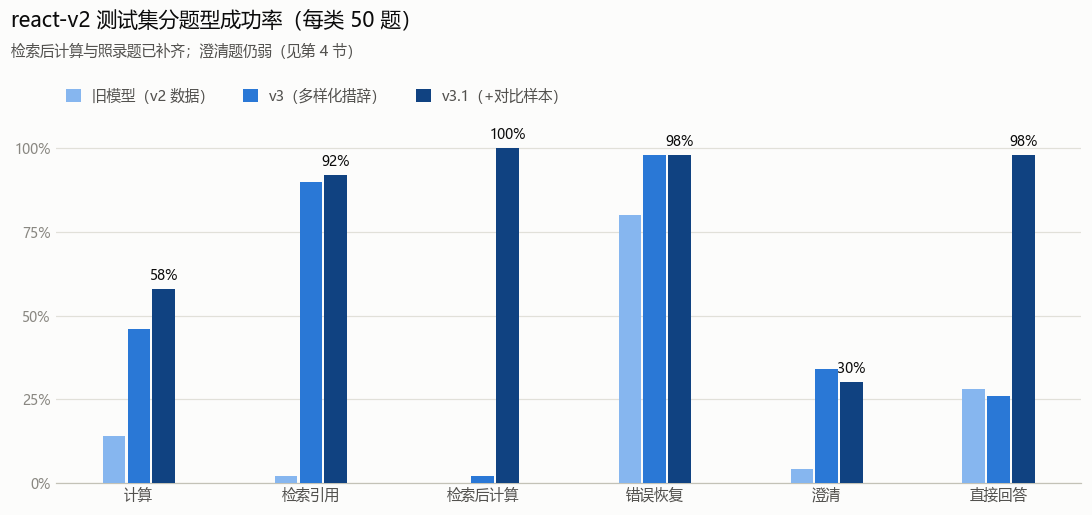

In [5]:
# 分题型：react-v2 测试集（每类 50 题，问法对新模型都没见过）
v2_test = list(EVAL_SETS)[1]
by_kind = pd.DataFrame([[results[v2_test, m][k + "_success"] * 100 for m in MODELS] for k in KINDS],
                       index=list(KINDS.values()), columns=MODELS)
display(by_kind.round(0))
grouped_bars(by_kind, "react-v2 测试集分题型成功率（每类 50 题）", "检索后计算与照录题已补齐；澄清题仍弱（见第 4 节）")

## 2. 到底有哪些工具？

- `search_ocean(query)`：本地海洋资料／模拟航次卡检索，返回文段、编号和来源。
- `marine_calculate(...)`：海里／公里、节／km/h、m/s 等单位换算；航程、航速和时间计算。

下面是**直接测试工具**，不是让模型回答。工具本身算对，不代表模型会正确调用它。模型没有 Shell、文件写入或任意代码执行工具。OceanInstruct 及模拟卡可能包含合成内容，不能当作真实航行决策依据。

In [6]:
for tool in TOOLS:
    print(tool["function"]["name"], "：", tool["function"]["description"])
env = ReactTools([])
try:
    for arguments in [
        {"operation": "convert", "value": 1, "from_unit": "nmi", "to_unit": "km"},
        {"operation": "convert", "value": 15, "from_unit": "kn", "to_unit": "km/h"},
        {"operation": "distance", "speed": 12, "hours": 3},
        {"operation": "distance", "speed": 12},  # 少一个参数：工具会报错
    ]:
        print(arguments, "→", env.execute({"name": "marine_calculate", "arguments": arguments}))
finally:
    env.db.close()

search_ocean ： 检索海洋资料或模拟航次卡，返回原文和编号。
marine_calculate ： convert换算；distance=速度×小时，time=距离/速度，speed=距离/小时。距离km，速度km/h，时间h。
{'operation': 'convert', 'value': 1, 'from_unit': 'nmi', 'to_unit': 'km'} → {'value': 1.852, 'unit': 'km'}
{'operation': 'convert', 'value': 15, 'from_unit': 'kn', 'to_unit': 'km/h'} → {'value': 27.78, 'unit': 'km/h'}
{'operation': 'distance', 'speed': 12, 'hours': 3} → {'value': 36.0, 'unit': 'km'}
{'operation': 'distance', 'speed': 12} → {'error': '操作或参数不正确'}


## 3. 加载两个模型

两个模型都用固定贪心生成：同样的输入总是给出同样的输出，可以复现。不重试到成功、不修正模型的工具参数。每题最多 6 轮生成、4 次工具调用、2048 tokens 上下文。

In [7]:
device = torch.device(DEVICE)
generators = {}
for name, path in WEIGHTS.items():
    model = MiniMindForCausalLM(MiniMindConfig(hidden_size=768, num_hidden_layers=8, use_moe=False))
    model.load_state_dict(torch.load(path, map_location="cpu", weights_only=True), strict=True)
    generators[name] = model_generator(model.to(device).eval(), tokenizer, device, sample=False, save_logps=False)
OUTPUT = ROOT / "artifacts/agent" / ("notebook-sdk-" + datetime.now().strftime("%Y%m%d-%H%M%S-%f"))
OUTPUT.mkdir(parents=True, exist_ok=False)
atomic_json(OUTPUT / "config.json", {
    "weights": {name: str(path) for name, path in WEIGHTS.items()},
    "weight_sha256": {name: file_hash(path) for name, path in WEIGHTS.items()},
    "adapter_sha256": file_hash(ROOT / "agent/sdk.py"), "sdk_version": version("openai-agents"),
    "device": DEVICE, "sample": False, "selection": "first task of each kind/type, no success filtering",
})
print("两个模型已加载。完整轨迹保存到：", OUTPUT)


def run_case(item, name, corpus):
    # Notebook 已有事件循环；在一个工作线程里调用现有的同步 SDK 入口。
    # SQLite 连接在同一线程创建、使用和关闭；逐个执行，不并发共享模型。
    env = ReactTools(corpus)
    try:
        if isinstance(item, str):
            return run(item, tokenizer, env, generators[name])
        return run_trajectory(item, tokenizer, env, generators[name])
    finally:
        env.db.close()


def show_trace(trace):
    calls = iter(trace["calls"])
    for i, step in enumerate(trace["rounds"], 1):
        print(f"  第 {i} 轮模型输出：{step['text']}")
        if step.get("action", {}).get("type") in {"tool", "invalid"}:
            call = next(calls, None)
            if call is None:
                print("    没有执行工具（请查看停止原因）")
                continue
            result = json.dumps(call["result"], ensure_ascii=False)
            print("    工具结果：", result if len(result) <= 220 else result[:220] + "……")
    print("  最终回答：", trace["final"] or "（未完成）", "｜停止原因：", trace["stop"], "｜工具调用：", len(trace["calls"]))
    if "metrics" in trace:
        print("  评分：", "✓ 成功" if trace["metrics"]["success"] else "✗ 失败")


async def compare(item, corpus, label="自定义"):
    """同一道题让两个模型各答一次。item 是数据集里的题（会评分）或一句自定义问题（不评分）。"""
    question = item if isinstance(item, str) else item["question"]
    print("=" * 72)
    print(f"【{label}】{question}")
    if not isinstance(item, str) and item.get("public"):
        print("公开场景（模拟故障／历史）：", json.dumps(item["public"], ensure_ascii=False))
    traces = {}
    for name in WEIGHTS:
        trace = await asyncio.to_thread(run_case, item, name, corpus)
        print(f"\n{name}：")
        show_trace(trace)
        atomic_json(OUTPUT / f"{SHORT[name]}-{datetime.now():%H%M%S%f}.json", {"question": question, "trace": trace})
        traces[name] = trace
    print()
    return traces


def verdicts(traces):
    return ["✓ 成功" if traces[name]["metrics"]["success"] else "✗ 失败" for name in WEIGHTS]

两个模型已加载。完整轨迹保存到： /home/anhuang/OceanHeart/artifacts/agent/notebook-sdk-20261007-131135-260043


## 4. 同一道题，新旧模型各答一次

和上一版 Notebook 相同：每类只取 react-v2 验证集中出现的**第一题**，不按结果挑题。问题和公开历史交给 Agent，标准答案只在执行后交给原评分器。上一版里旧模型在计算、错误恢复、澄清这三题上失败。

「错误恢复」题会注入一次明确标记的模拟工具故障；「澄清」和「直接回答」可能无需调用工具。

In [8]:
tasks_v2_val = read_jsonl(REACT_V2 / "ocean_agent_val.jsonl")
corpus_v2_val = read_jsonl(REACT_V2 / "ocean_agent_corpus_val.jsonl")
summary = []
for kind, label in KINDS.items():
    task = next(t for t in tasks_v2_val if t["kind"] == kind)
    summary.append([label, *verdicts(await compare(task, corpus_v2_val, label))])
pd.DataFrame(summary, columns=["题型", *WEIGHTS]).set_index("题型")

【计算】海洋调查记录处理：已知航速6.2 km/h与航行时长1.7 h，求调查船走过的距离。只回答数值和单位。



旧模型（v2 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "已知航速6.2 km/h与航行时长1.7 h"}}</tool_call>
    工具结果： {"documents": []}
  第 2 轮模型输出：<clarify>未找到航速6.2 km/h与航行时长1.7 h</clarify>
  最终回答： 未找到航速6.2 km/h与航行时长1.7 h ｜停止原因： clarify ｜工具调用： 1
  评分： ✗ 失败



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "distance", "speed": 6.2, "hours": 1.7}}</tool_call>
    工具结果： {"value": 10.54, "unit": "km"}
  第 2 轮模型输出：<final>10.54 km</final>
  最终回答： 10.54 km ｜停止原因： final ｜工具调用： 1
  评分： ✓ 成功

【检索引用】海洋调查记录处理：请为问题‘宽壳全海笋的受精卵在发育过程中纺锤体的作用是什么？’找出资料中的一句原文，并附上[文档编号]。



旧模型（v2 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "请为问题‘宽壳全海笋的受精卵在发育过程中纺锤体的作用是什么？"}}</tool_call>
    工具结果： {"documents": [{"id": "O6fb9da0f92", "source": "OceanInstruct-v0.2", "excerpt": "a. 染色体排列与分离：纺锤体在细胞分裂过程中形成，其纤维结构将染色体精确排列在赤道板（细胞中央平面）上，确保后续的均等分离。"}]}
  第 2 轮模型输出：<final>a. 染色体排列与分离：纺锤体在细胞分裂过程中形成，其纤维结构将染色体精确排列在赤道板（细胞中央平面）上，确保后续的均等分离。[O6fb9da0f92]</final>
  最终回答： a. 染色体排列与分离：纺锤体在细胞分裂过程中形成，其纤维结构将染色体精确排列在赤道板（细胞中央平面）上，确保后续的均等分离。[O6fb9da0f92] ｜停止原因： final ｜工具调用： 1
  评分： ✓ 成功



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "宽壳全海笋的受精卵在发育过程中纺锤体的作用是什么？"}}</tool_call>
    工具结果： {"documents": [{"id": "O6fb9da0f92", "source": "OceanInstruct-v0.2", "excerpt": "a. 染色体排列与分离：纺锤体在细胞分裂过程中形成，其纤维结构将染色体精确排列在赤道板（细胞中央平面）上，确保后续的均等分离。"}]}
  第 2 轮模型输出：<final>a. 染色体排列与分离：纺锤体在细胞分裂过程中形成，其纤维结构将染色体精确排列在赤道板（细胞中央平面）上，确保后续的均等分离。[O6fb9da0f92]</final>
  最终回答： a. 染色体排列与分离：纺锤体在细胞分裂过程中形成，其纤维结构将染色体精确排列在赤道板（细胞中央平面）上，确保后续的均等分离。[O6fb9da0f92] ｜停止原因： final ｜工具调用： 1
  评分： ✓ 成功

【检索后计算】海洋调查记录处理：请根据模拟航次卡 C6e9eec9f15的航速和时长确定总里程，统一以km表示。只回答数值和单位。


...


旧模型（v2 数据）：
  第 1 轮模型输出：<clarify>请找出航次missingf31fb857fa的资料；无法定位时请告诉我需补充的信息。</clarify>
  最终回答： 请找出航次missingf31fb857fa的资料；无法定位时请告诉我需补充的信息。 ｜停止原因： clarify ｜工具调用： 0
  评分： ✗ 失败



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "missingf31fb857fa"}}</tool_call>
    工具结果： {"documents": []}
  第 2 轮模型输出：<clarify>资料库中未找到该航次资料，请补充正确的编号或原始资料。</clarify>
  最终回答： 资料库中未找到该航次资料，请补充正确的编号或原始资料。 ｜停止原因： clarify ｜工具调用： 1
  评分： ✓ 成功

【直接回答】海洋调查记录处理：请照录这份已确认海洋记录的内容：i. 由于其多孔结构提供了更大的表面积和生态位，通常支持更高多样性的微生物群落。 不要添加别的文字。



旧模型（v2 数据）：
  第 1 轮模型输出：<final>i. 由于其多孔结构提供了更大的表面积和生态位，通常支持更高多样性的微生物群落。</final>
  最终回答： i. 由于其多孔结构提供了更大的表面积和生态位，通常支持更高多样性的微生物群落。 ｜停止原因： final ｜工具调用： 0
  评分： ✓ 成功



新模型（v3.1 数据）：
  第 1 轮模型输出：<final>i. 由于其多孔结构提供了更大的表面积和生态位，通常支持更高多样性的微生物群落。</final>
  最终回答： i. 由于其多孔结构提供了更大的表面积和生态位，通常支持更高多样性的微生物群落。 ｜停止原因： final ｜工具调用： 0
  评分： ✓ 成功



,旧模型（v2 数据）,新模型（v3.1 数据）
题型,,
计算,✗ 失败,✓ 成功
检索引用,✓ 成功,✓ 成功
检索后计算,✓ 成功,✓ 成功
错误恢复,✗ 失败,✓ 成功
澄清,✗ 失败,✓ 成功
直接回答,✓ 成功,✓ 成功


## 5. 上一轮的典型失败，现在怎么样

从 react-v2 测试集各取下面四种题的**第一题**（同样不挑题）：

- 检索后计算（“需要补全km制航程报表”这类填报表问法）：v3 曾经查到卡片就把原文当答案。
- 【】包裹的照录：v3 曾经把括号外的说明抄了出来。
- 编号＋缺航速：**仍是难点**，新模型通常会先检索编号再说“未找到资料”。
- 两条记录冲突：**仍是难点**，新模型会把两条记录并排列出，但常常说错冲突的字段。

In [9]:
tasks_v2_test = read_jsonl(REACT_V2 / "ocean_agent_test.jsonl")
corpus_v2_test = read_jsonl(REACT_V2 / "ocean_agent_corpus_test.jsonl")
cases = {
    "检索后计算（填报表问法）": lambda t: t["kind"] == "chain",
    "【】包裹的照录": lambda t: t["kind"] == "direct",
    "编号＋缺航速（难点）": lambda t: t["kind"] == "clarify" and t.get("no_tools"),
    "两条记录冲突（难点）": lambda t: t["kind"] == "clarify" and len(t.get("required_docs", [])) == 2,
}
summary = []
for label, match in cases.items():
    task = next(t for t in tasks_v2_test if match(t))
    summary.append([label, *verdicts(await compare(task, corpus_v2_test, label))])
pd.DataFrame(summary, columns=["类型", *WEIGHTS]).set_index("类型")

【检索后计算（填报表问法）】请完成以下海上作业资料核对，并遵循输出要求：需要补全km制航程报表，已知依据仅有模拟航次卡 C8bcb020791，请给出应填写的航程。只回答数值和单位。



旧模型（v2 数据）：
  第 1 轮模型输出：<final>请补全km制航程报表，已知依据仅有模拟航次卡 C8bc020791，请补全km制航程报表，已知依据仅有模拟航次卡 C8bc020791，请补全km制航程报表，已知依据仅有模拟航次卡 C8bc020791，请补全km制航程报表，已知依据仅有模拟航次卡 C8bc020791，请补全km制航程报表，已知依据仅有模拟航次卡 C8bc020791，请补全km制航程报表，已知依据仅有模拟航次卡 C8bc020791，请补全km制航程
  最终回答： （未完成） ｜停止原因： generation_limit ｜工具调用： 0
  评分： ✗ 失败



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "C8bcb020791"}}</tool_call>
    工具结果： {"documents": [{"id": "C8bcb020791", "source": "synthetic-v2", "excerpt": "合成练习，非实测：speed=33.4 kn，hours=8.4 h。"}]}
  第 2 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "convert", "value": 33.4, "from_unit": "kn", "to_unit": "km/h"}}</tool_call>
    工具结果： {"value": 61.8568, "unit": "km/h"}
  第 3 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "distance", "speed": 61.8568, "hours": 8.4}}</tool_call>
    工具结果： {"value": 519.59712, "unit": "km"}
  第 4 轮模型输出：<final>519.59712 km</final>
  最终回答： 519.59712 km ｜停止原因： final ｜工具调用： 3
  评分： ✓ 成功

【【】包裹的照录】请完成以下海上作业资料核对，并遵循输出要求：这是全部需要使用的资料：【a. 围垦工程直接占用潮滩和浅水区域，导致原本在此沉积的泥沙被迫向其他区域扩散。】。请只输出括号内的原文，不作外部查询。

旧模型（v2 数据）：
  第 1 轮模型输出：<final>这是全部需要使用的资料。</final>
  最终回答： 这是全部需要使用的资料。 ｜停止原因： final ｜工具调用： 0
  评分： ✗ 失败



新模型（v3.1 数据）：
  第 1 轮模型输出：<final>a. 围垦工程直接占用潮滩和浅水区域，导致原本在此沉积的泥沙被迫向其他区域扩散。</final>
  最终回答： a. 围垦工程直接占用潮滩和浅水区域，导致原本在此沉积的泥沙被迫向其他区域扩散。 ｜停止原因： final ｜工具调用： 0
  评分： ✓ 成功

【编号＋缺航速（难点）】请完成以下海上作业资料核对，并遵循输出要求：请为编号7d02d3384e的调查航次补填航程。日志只提供航行时长，尚无船速数据。



旧模型（v2 数据）：
  第 1 轮模型输出：<final>7d02d3384e的调查航次补填航次。</final>
  最终回答： 7d02d3384e的调查航次补填航次。 ｜停止原因： final ｜工具调用： 0
  评分： ✗ 失败



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "7d02d3384e"}}</tool_call>
    工具结果： {"documents": []}
  第 2 轮模型输出：<clarify>资料库中未找到该航次资料，请补充正确的编号或原始资料。</clarify>
  最终回答： 资料库中未找到该航次资料，请补充正确的编号或原始资料。 ｜停止原因： clarify ｜工具调用： 1
  评分： ✗ 失败

【两条记录冲突（难点）】请完成以下海上作业资料核对，并遵循输出要求：以模拟冲突航次卡 X6d7f4fbe22为依据填写航程；不允许自行选择互相矛盾的数据，请说明待确认事项。



旧模型（v2 数据）：
  第 1 轮模型输出：<final>未找到航速或速度的航速或速度，请补充正确的航速或速度。</final>
  最终回答： 未找到航速或速度的航速或速度，请补充正确的航速或速度。 ｜停止原因： final ｜工具调用： 0
  评分： ✗ 失败



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "X6d7f4fbe22"}}</tool_call>
    工具结果： {"documents": [{"id": "X6d7f4fbe22a", "source": "synthetic-v2", "excerpt": "合成练习，同日未核实记录：speed=28 km/h，hours=2.4 h。"}, {"id": "X6d7f4fbe22b", "source": "synthetic-v2", "excerpt": "合成练习，同日未核实记录：speed=33 km/h，hours=2.4 h。"……
  第 2 轮模型输出：<plan>航速：28 km/h，33 km/h；航行时长：2.4 h，2.4 h。</plan><clarify>资料中的航行时长存在冲突，请确认应采用哪条记录。</clarify>
  最终回答： 资料中的航行时长存在冲突，请确认应采用哪条记录。 ｜停止原因： clarify ｜工具调用： 1
  评分： ✗ 失败



,旧模型（v2 数据）,新模型（v3.1 数据）
类型,,
检索后计算（填报表问法）,✗ 失败,✓ 成功
【】包裹的照录,✗ 失败,✓ 成功
编号＋缺航速（难点）,✗ 失败,✗ 失败
两条记录冲突（难点）,✗ 失败,✗ 失败


## 6. 自己出题

- 修改下面 `QUESTIONS` 列表（或最后一格的 `QUESTION`）后运行；每个问题都会让两个模型各答一次。
- 自定义问题没有标准答案，**不打分**，只看过程：选没选对工具、参数和题目是否一致、读没读懂工具结果、该反问时有没有反问。
- 资料库使用 react-v3.1 验证集的本地资料（OceanInstruct 摘录＋合成航次卡）。下一格会列出几张航次卡和几个资料题目，复制编号或题目即可提问。不联网；不保证能检索到任意主题。
- 训练数据覆盖的范围：单步计算、最多一次单位换算后再计算、查航次卡后计算、检索引用、缺信息时反问。超出这个范围的问题（例如需要两次换算）新模型通常做不对。

In [10]:
custom_corpus = read_jsonl(REACT_V31 / "ocean_agent_corpus_val.jsonl")
custom_tasks = read_jsonl(REACT_V31 / "ocean_agent_val.jsonl")
per_title = Counter(d["title"] for d in custom_corpus)
print("可用的模拟航次卡（编号 → 卡片内容）：")
for d in [d for d in custom_corpus if d["source"] == "synthetic-v3" and per_title[d["title"]] == 1][:6]:
    print(f"  {d['title'].split()[-1]}：{d['excerpt']}")
print("\n两条记录互相冲突的航次卡：", "、".join(t.split()[-1] for t in sorted(t for t, n in per_title.items() if n == 2)[:3]))
print("\n可检索的资料题目：")
for d in [d for d in custom_corpus if d["source"] == "OceanInstruct-v0.2"][:4]:
    print(f"  {d['title']}")

可用的模拟航次卡（编号 → 卡片内容）：
  Cbac516c676：合成练习，非实测：航速13.2 km/h，航行17 h。
  K83435106f6：合成练习，非实测：航段长 515 km；航时 9.8 hours。
  logabc6b33692：合成练习，非实测：计划航程 506.2 km；计划船速 24 km/h。
  C2ce7a883bc：合成练习，非实测：航速24.8 kn，航行3 hours。
  trip06b1a5e415：合成练习，非实测：航段长 20450 m；航时 21 hours。
  R66473aeba2：合成练习，非实测：计划航程 150 nautical miles；计划船速 19 km/h。

两条记录互相冲突的航次卡： C10b3b0ddbb、C29868ff90c、C6fce9edda5

可检索的资料题目：
  在模拟三维海洋环境中的波浪-结构相互作用时，需要考虑哪些计算因素？
  紫外线照射对海洋贝类精子的遗传物质灭活机制是什么？
  海水中的非离子氨对海洋生物的毒性机制是什么？
  海洋鱼类在缺乏维生素时会出现哪些健康问题？


In [11]:
card = next(t["query"] for t in custom_tasks if t["kind"] == "chain" and t["subtype"].startswith("distance:"))
topic = next(t["query"] for t in custom_tasks if t["kind"] == "retrieve" and t["subtype"] == "retrieve")
QUESTIONS = [
    "船速为12 km/h，航行3 h，航程是多少km？请调用工具计算。",  # 上一版 Notebook 中旧模型填错参数的题
    f"根据航次卡{card}，算一下这艘船的航程。",                  # 先检索航次卡，再计算
    f"帮我查一下资料：{topic} 只要原文和[文档编号]。",           # 检索并引用原文
    "船开了5个小时，航程是多少？",                              # 缺航速：应该反问，而不是编一个数
    # 下面两题都需要两次单位换算（共 3 步计算），v3.1 训练数据里每题最多一次换算：
    "一艘科考船以15节的速度开了4个小时，一共走了多少海里？",   # 节→km/h，算航程，再 km→海里
    "航程120海里，船速20节，需要航行多久？",                   # 海里→km 和 节→km/h，再算时间
]
for question in QUESTIONS:
    await compare(question, custom_corpus)

【自定义】船速为12 km/h，航行3 h，航程是多少km？请调用工具计算。



旧模型（v2 数据）：
  第 1 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "convert", "value": 12.0, "from_unit": "km/h"}}</tool_call>
    工具结果： {"error": "操作或参数不正确"}
  第 2 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "distance", "speed": 12.0, "from_unit": "km/h"}}</tool_call>
    工具结果： {"error": "操作或参数不正确"}
  第 3 轮模型输出：<final>操作或参数不正确</final>
  最终回答： 操作或参数不正确 ｜停止原因： final ｜工具调用： 2



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "distance", "speed": 12.0, "hours": 3.0}}</tool_call>
    工具结果： {"value": 36.0, "unit": "km"}
  第 2 轮模型输出：<final>36.0 km</final>
  最终回答： 36.0 km ｜停止原因： final ｜工具调用： 1

【自定义】根据航次卡trip726daaf10a，算一下这艘船的航程。



旧模型（v2 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "这艘船的航速？"}}</tool_call>
    工具结果： {"documents": []}
  第 2 轮模型输出：<clarify>未找到航次卡，请补充正确的航速。</clarify>
  最终回答： 未找到航次卡，请补充正确的航速。 ｜停止原因： clarify ｜工具调用： 1



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "search_ocean", "arguments": {"query": "trip726daaf10a"}}</tool_call>
    工具结果： {"documents": [{"id": "trip726daaf10a", "source": "synthetic-v3", "excerpt": "合成练习，非实测：航速3.2 kn，航行3.2 hours。"}]}
  第 2 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "convert", "value": 3.2, "from_unit": "kn", "to_unit": "km/h"}}</tool_call>
    工具结果： {"value": 5.9264, "unit": "km/h"}
  第 3 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "distance", "speed": 5.9264, "hours": 3.2}}</tool_call>
    工具结果： {"value": 18.96448, "unit": "km"}
  第 4 轮模型输出：<final>18.96448 km</final>
  最终回答： 18.96448 km ｜停止原因： final ｜工具调用： 3

【自定义】帮我查一下资料：如何通过海洋要素场的空间配置来优化渔场的捕捞策略？ 只要原文和[文档编号]。


...


新模型（v3.1 数据）：
  第 1 轮模型输出：<clarify>缺少航速，请补充航速的数值和单位。</clarify>
  最终回答： 缺少航速，请补充航速的数值和单位。 ｜停止原因： clarify ｜工具调用： 0

【自定义】一艘科考船以15节的速度开了4个小时，一共走了多少海里？



旧模型（v2 数据）：
  第 1 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "speed", "distance": 4.0, "speed": 15.0}}</tool_call>
    工具结果： {"error": "操作或参数不正确"}
  第 2 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "distance", "speed": 15.0, "hours": 4.0}}</tool_call>
    工具结果： {"value": 60.0, "unit": "km"}
  第 3 轮模型输出：<final>60.0 km</final>
  最终回答： 60.0 km ｜停止原因： final ｜工具调用： 2



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "convert", "value": 15.0, "from_unit": "kn", "to_unit": "nmi"}}</tool_call>
    工具结果： {"error": "不能跨量纲换算"}
  第 2 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "convert", "value": 15.0, "from_unit": "kn", "to_unit": "nmi"}}</tool_call>
    工具结果： {"error": "repeated_failed_call: change arguments or clarify", "retryable": false}
  第 3 轮模型输出：<final>repeated_failed_call: change arguments or clarify</final>
  最终回答： repeated_failed_call: change arguments or clarify ｜停止原因： final ｜工具调用： 2

【自定义】航程120海里，船速20节，需要航行多久？



旧模型（v2 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "convert", "value": 120.0, "from_unit": "marine_calculate", "value": 120.0, "from_unit": "marine_calculate", "value": 120.0, "from_unit": "distance", "speed": 120.0, "from_unit": "distance", "speed": 120.0, "from_unit": "distance", "speed": 120.0, "from_unit": "distance", "speed": 120.0, "from_unit": "distance", "
  最终回答： （未完成） ｜停止原因： generation_limit ｜工具调用： 0



新模型（v3.1 数据）：
  第 1 轮模型输出：<clarify>缺少航速，请补充航速的数值和单位。</clarify>
  最终回答： 缺少航速，请补充航速的数值和单位。 ｜停止原因： clarify ｜工具调用： 0



**上面默认问题的结果（贪心生成，重跑结果相同）**：新模型答对了单步计算、查卡后计算、检索引用，并在缺航速时正确反问；旧模型这几题大多失败。最后两题需要两次单位换算，超出了 v3.1 训练数据的覆盖范围，新模型也失败了：一题尝试“节→海里”这种跨量纲换算，报错后把错误信息当成了答案；另一题误以为缺少航速而反问。这是下一轮补数据可以覆盖的方向。

In [12]:
QUESTION = "调查船以18节航行了2.5小时，航程是多少公里？"  # 改成你自己的问题后运行本格
await compare(QUESTION, custom_corpus);

【自定义】调查船以18节航行了2.5小时，航程是多少公里？



旧模型（v2 数据）：
  第 1 轮模型输出：<plan>先查找相关海洋资料。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "speed", "distance": 2.5, "hours": 2.5}}</tool_call>
    工具结果： {"value": 1.0, "unit": "km/h"}
  第 2 轮模型输出：<final>1.0 km/h</final>
  最终回答： 1.0 km/h ｜停止原因： final ｜工具调用： 1



新模型（v3.1 数据）：
  第 1 轮模型输出：<plan>按已知数值与单位计算。</plan><tool_call>{"name": "marine_calculate", "arguments": {"operation": "convert", "value": 2.5, "from_unit": "kn", "to_unit": "km/h"}}</tool_call>
    工具结果： {"value": 4.63, "unit": "km/h"}
  第 2 轮模型输出：<final>4.63 km/h</final>
  最终回答： 4.63 km/h ｜停止原因： final ｜工具调用： 1



**这一格默认问题的结果**：它在训练覆盖范围内（一次换算再计算），新模型也选对了“先把节换算成 km/h”，但把时长 2.5 当成航速填了进去，换算完就直接交了答案。填错数字、换算后提前作答，正是计算题在 react-v2 测试上仍有约四成失败的典型错法。

## 结束

观察重点：模型选对工具了吗？参数与题目一致吗？读懂工具结果了吗？失败后是否修正／澄清？

- 换权重：修改第一格的 `WEIGHTS`（例如加入 `out/ocean_react-v3-20261006-1314-fixed-sft_best_768.pth` 看 v3）。
- 关闭 Notebook 内核可释放显存。此文件不训练模型、不上传 SwanLab；训练与评估见 [ReAct v3 数据说明](REACT_V3_DATA.md)。

SDK 循环职责参考：[OpenAI 官方运行说明](https://developers.openai.com/api/docs/guides/agents/running-agents)。